In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Makes plots look clean
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully")

Libraries loaded successfully


In [38]:
df = pd.read_csv('../data/churn.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [39]:
print("Data types:\n")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nChurn distribution:")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Data types:

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Paper

In [40]:
# Fix TotalCharges: convert to numeric, blank strings become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many became NaN
print("NaN in TotalCharges after conversion:", df['TotalCharges'].isnull().sum())

# These are new customers with 0 tenure — drop them (only ~11 rows)
df.dropna(subset=['TotalCharges'], inplace=True)

# Convert Churn to binary: Yes=1, No=0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop customerID — it's just an identifier, no analytical value
df.drop(columns=['customerID'], inplace=True)

print("Cleaned dataset shape:", df.shape)
print("Churn rate:", round(df['Churn'].mean() * 100, 2), "%")

NaN in TotalCharges after conversion: 11
Cleaned dataset shape: (7032, 20)
Churn rate: 26.58 %


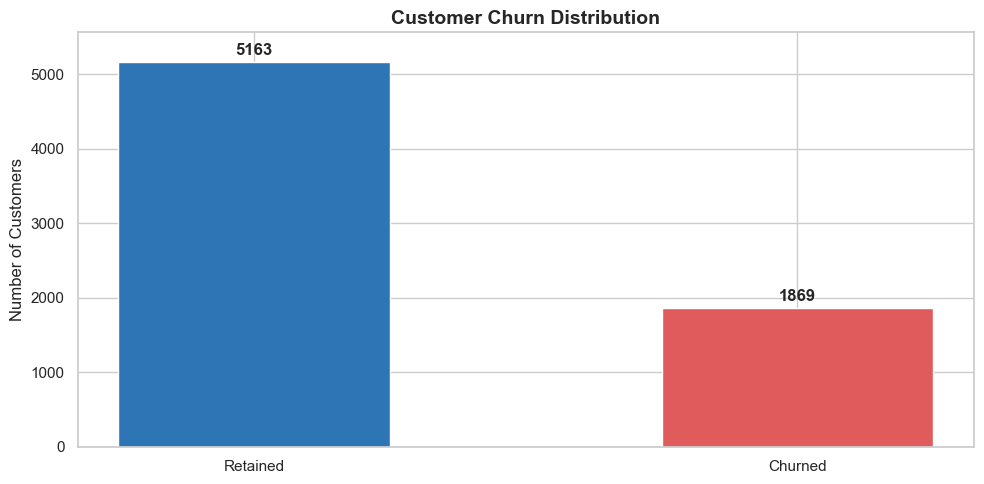

Churn rate: 26.6% of customers churned


In [41]:
fig, ax = plt.subplots()
counts = df['Churn'].value_counts()
bars = ax.bar(['Retained', 'Churned'], counts.values, color=['#2E75B6', '#E05C5C'], width=0.5)

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(count), ha='center', va='bottom', fontweight='bold')

ax.set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, counts.max() + 400)
plt.tight_layout()
plt.savefig('../data/churn_distribution.png', bbox_inches='tight')
plt.show()
print(f"Churn rate: {df['Churn'].mean()*100:.1f}% of customers churned")

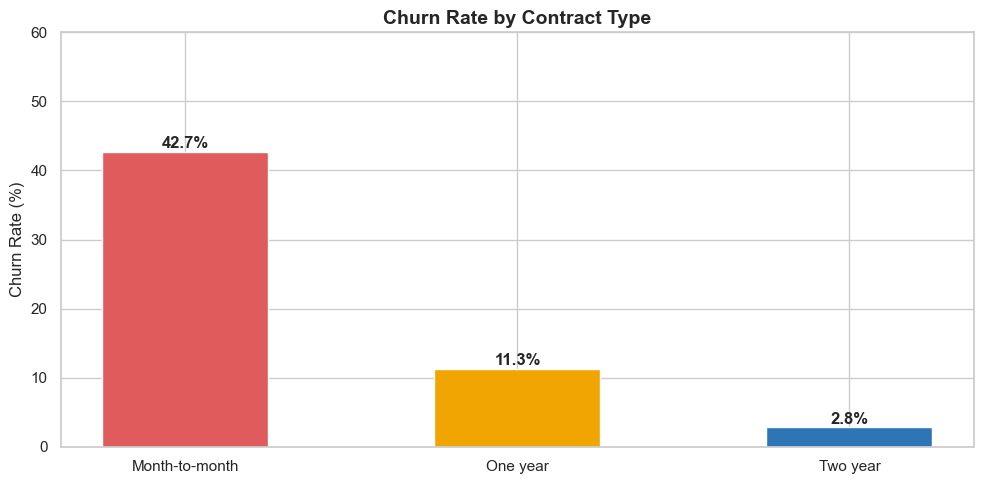

In [42]:
contract_churn = df.groupby('Contract')['Churn'].mean().mul(100).round(1).reset_index()
contract_churn.columns = ['Contract Type', 'Churn Rate (%)']

fig, ax = plt.subplots()
bars = ax.bar(contract_churn['Contract Type'], contract_churn['Churn Rate (%)'],
              color=['#E05C5C', '#F0A500', '#2E75B6'], width=0.5)

for bar, val in zip(bars, contract_churn['Churn Rate (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontweight='bold')

ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 60)
plt.tight_layout()
plt.savefig('../data/contract_churn.png', bbox_inches='tight')
plt.show()

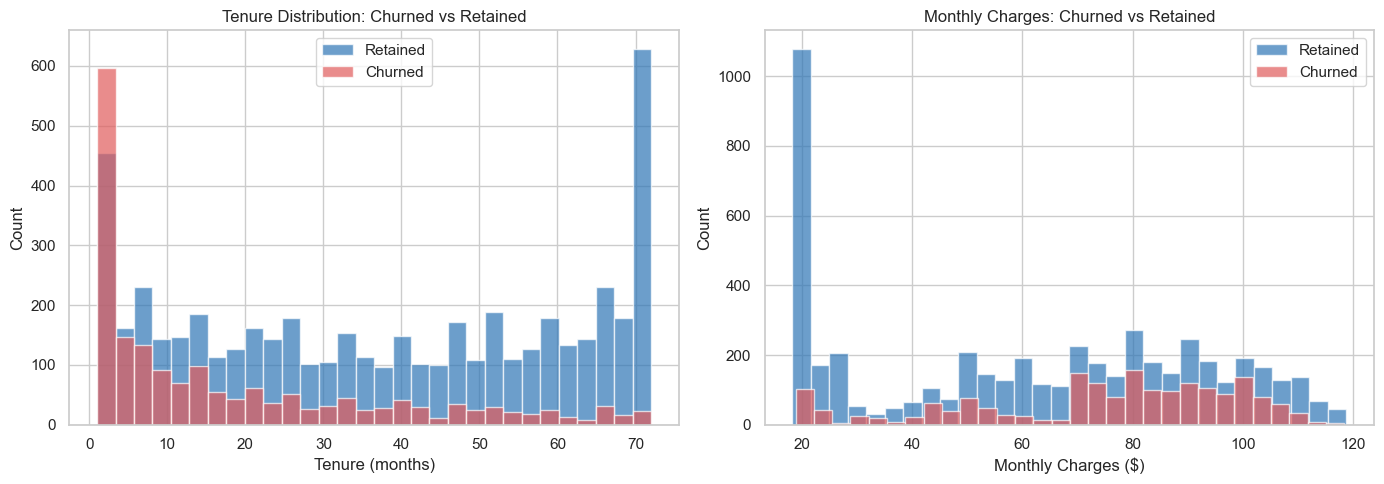

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure distribution by churn
axes[0].hist(df[df['Churn']==0]['tenure'], bins=30, alpha=0.7, color='#2E75B6', label='Retained')
axes[0].hist(df[df['Churn']==1]['tenure'], bins=30, alpha=0.7, color='#E05C5C', label='Churned')
axes[0].set_title('Tenure Distribution: Churned vs Retained')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Monthly charges vs churn
axes[1].hist(df[df['Churn']==0]['MonthlyCharges'], bins=30, alpha=0.7, color='#2E75B6', label='Retained')
axes[1].hist(df[df['Churn']==1]['MonthlyCharges'], bins=30, alpha=0.7, color='#E05C5C', label='Churned')
axes[1].set_title('Monthly Charges: Churned vs Retained')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/tenure_charges.png', bbox_inches='tight')
plt.show()

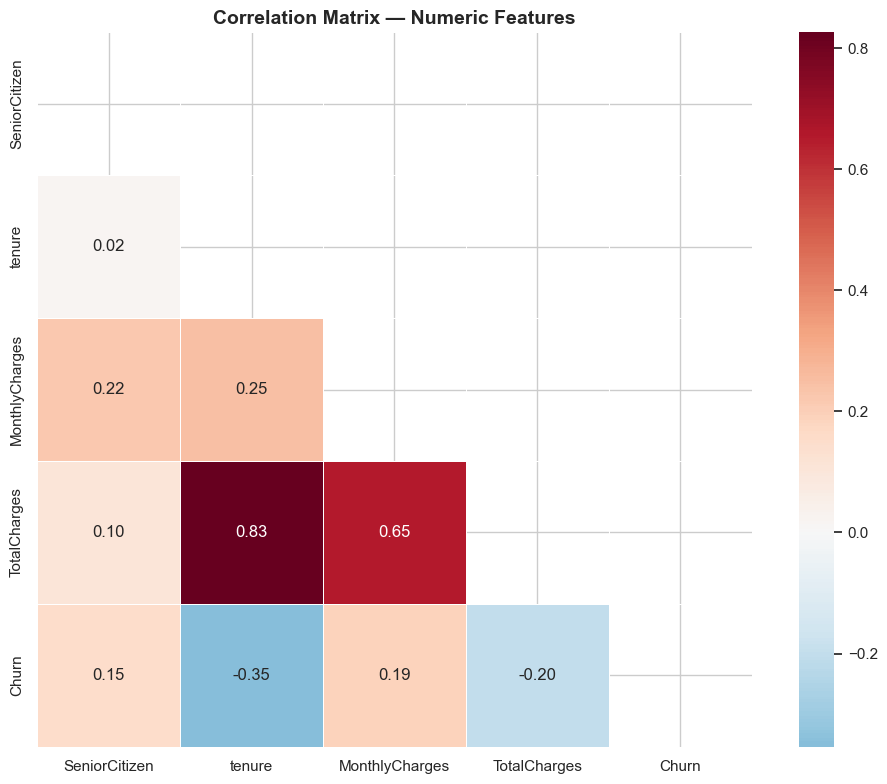

In [44]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))  # hide upper triangle
sns.heatmap(numeric_df.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [45]:
print("=" * 55)
print("   CUSTOMER CHURN ANALYSIS — KEY FINDINGS")
print("=" * 55)

total = len(df)
churned = df['Churn'].sum()
churn_rate = churned / total * 100

print(f"\n📊 Dataset: {total:,} customers | {churned:,} churned ({churn_rate:.1f}%)")

print("\n🔑 Top Churn Drivers:")
print(f"   • Month-to-month contracts: {df[df['Contract']=='Month-to-month']['Churn'].mean()*100:.1f}% churn rate")
print(f"   • Two-year contracts: {df[df['Contract']=='Two year']['Churn'].mean()*100:.1f}% churn rate")

early = df[df['tenure'] <= 12]['Churn'].mean() * 100
late  = df[df['tenure'] > 24]['Churn'].mean() * 100
print(f"   • Customers in first 12 months: {early:.1f}% churn rate")
print(f"   • Customers beyond 24 months:  {late:.1f}% churn rate")

high_bill = df[df['MonthlyCharges'] > 70]['Churn'].mean() * 100
low_bill  = df[df['MonthlyCharges'] <= 70]['Churn'].mean() * 100
print(f"   • High monthly charges (>$70): {high_bill:.1f}% churn rate")
print(f"   • Lower monthly charges (≤$70): {low_bill:.1f}% churn rate")

print("\n💡 Business Recommendations:")
print("   1. Offer discounts to convert month-to-month users to annual plans")
print("   2. Prioritise retention campaigns in the first 12 months")
print("   3. Review pricing strategy for high-charge customers")
print("=" * 55)

   CUSTOMER CHURN ANALYSIS — KEY FINDINGS

📊 Dataset: 7,032 customers | 1,869 churned (26.6%)

🔑 Top Churn Drivers:
   • Month-to-month contracts: 42.7% churn rate
   • Two-year contracts: 2.8% churn rate
   • Customers in first 12 months: 47.7% churn rate
   • Customers beyond 24 months:  14.0% churn rate
   • High monthly charges (>$70): 35.4% churn rate
   • Lower monthly charges (≤$70): 17.4% churn rate

💡 Business Recommendations:
   1. Offer discounts to convert month-to-month users to annual plans
   2. Prioritise retention campaigns in the first 12 months
   3. Review pricing strategy for high-charge customers
